In [1]:
!pip install plotly


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [502]:
!pip install plotly pandas


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [777]:
!pip install pycountry

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------------------ --------------------- 3.7/8.0 MB 31.0 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 27.6 MB/s  0:00:00



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [848]:
!pip install patsy 


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [850]:
!pip install Pylance

   ---------------------------------------- 0.0/74.8 MB ? eta -:--:--
   --- ------------------------------------ 6.0/74.8 MB 33.7 MB/s eta 0:00:03
   ----- ---------------------------------- 10.0/74.8 MB 25.9 MB/s eta 0:00:03
   ------ --------------------------------- 11.5/74.8 MB 19.0 MB/s eta 0:00:04
   ------- -------------------------------- 14.7/74.8 MB 17.8 MB/s eta 0:00:04
   --------- ------------------------------ 17.3/74.8 MB 16.8 MB/s eta 0:00:04
   ---------- ----------------------------- 20.4/74.8 MB 16.6 MB/s eta 0:00:04
   ------------- -------------------------- 26.0/74.8 MB 17.9 MB/s eta 0:00:03
   ---------------- ----------------------- 30.1/74.8 MB 18.2 MB/s eta 0:00:03
   ------------------ --------------------- 35.4/74.8 MB 19.1 MB/s eta 0:00:03
   ---------------------- ----------------- 41.2/74.8 MB 19.7 MB/s eta 0:00:02
   ------------------------- -------------- 46.9/74.8 MB 20.5 MB/s eta 0:00:02
   ---------------------------- ----------- 52.4/74.8 MB 21.0 


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Agriculture R&D Study - EDA

**Yelizaveta Kabanova - May/June 2026**

The main **objective** of this study is to investigate whether the effects of agricultural R&D investments differ across groups of structurally similar countries and whether these effects emerge over different time horizons. The study proposes a cluster-based dynamic response analysis framework that allows to identify different investment response profiles by estimating cluster-specific dynamic production responses to investment over time. 
Сountries are grouped into clusters based on economic, demographic, and environmental characteristics in order to identify cluster-specific investment horizons and characterise distinct response profiles. 

**The research hypothesis are as follows:**
- H1: Countries can be classified into distinct clusters based on economic, demographic and environmental characteristics.
- H2: The magnitude and timing of agricultural R&D effects differ across country clusters.
- H3: The causal effect of agricultural R&D investments is heterogeneous across country clusters.

**The objectives of this study are to:**
- construct a cross-country dataset by combining agricultural, economic, demographic, environmental, and R&D indicators;
- identify groups of structurally similar countries using clustering techniques;
- estimate the lagged effects of agricultural R&D investments on agricultural production within each cluster. 
- compare investment horizons across country clusters. 
- formulate cluster-specific structural response profiles based on observed dynamic effects.

In [1]:
import numpy as np
import pandas as pd
import pathlib 
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import pycountry
import plotly.express as px
from scipy.stats import zscore
import statsmodels.formula.api as smf
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score # mean_squared_error, mean_absolute_error, r2_score, 

import warnings
from pandas.errors import SettingWithCopyWarning
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))

sns.set_style("darkgrid")
sns.set_theme(palette="muted")

## Data Load

In [6]:
def read_csv(path):
    return pd.read_csv(path)

def print_unique(df, name='None'):
    print(f'\n-- {name} --\n{df["Country"].unique()}')

In [10]:
DIR = pathlib.Path(r"C:\Users\eliza\Portfolio\agricultural_investments")
DATA_DIR = pathlib.Path(r"C:\Users\eliza\Portfolio\agricultural_investments\data")

df = pd.read_csv(DATA_DIR / "merged_dataset.csv")

# RD = read_csv(DATA_DIR / 'Agricultural R&D Investment.csv')   
# PROD = read_csv(DATA_DIR / 'Value of Agricultural Production.csv')
# GDP = read_csv(DATA_DIR / 'GDP.csv')
# POP = read_csv(DATA_DIR / 'Population Total.csv')
# POP_RUR = read_csv(DATA_DIR / 'Rural Population.csv')
# RUR_LAND = read_csv(DATA_DIR / 'Rural Land.csv')
# TEMP = read_csv(DATA_DIR / 'Average Temperature.csv')

## Explorary Data Analysis (EDA)

### 1. Dataset Overview

In [11]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country         1080 non-null   object 
 1   year            1080 non-null   int64  
 2   rd              1080 non-null   float64
 3   production      1080 non-null   float64
 4   gdp_per_capita  1080 non-null   float64
 5   population      1080 non-null   float64
 6   rural_pop_pct   1080 non-null   float64
 7   rural_land_pct  1080 non-null   float64
 8   temperature     1080 non-null   float64
 9   log_population  1080 non-null   float64
 10  log_production  1080 non-null   float64
 11  log_rd          1080 non-null   float64
dtypes: float64(10), int64(1), object(1)
memory usage: 101.4+ KB


,Country,year,rd,production,gdp_per_capita,population,rural_pop_pct,rural_land_pct,temperature,log_population,log_production,log_rd
0,Algeria,2009,71.2560,16448620.0,4235.429905,35490445.0,33.490262,17.373853,23.87,17.384774,16.615752,4.280215
1,Algeria,2010,66.0857,17377479.0,4912.785855,36188236.0,32.876494,17.371334,24.09,17.404245,16.670686,4.205971
2,Algeria,2011,77.6880,19071549.0,5916.313644,36903376.0,32.265599,17.377212,23.78,17.423814,16.763708,4.365491
3,Algeria,2012,84.0305,20623559.0,6033.648847,37646166.0,31.657874,17.381490,23.74,17.443742,16.841945,4.443010
4,Antigua and Barbuda,2007,1.3190,24711.0,18204.512400,81704.0,72.279873,20.454545,24.91,11.310870,10.115044,0.841136


In [12]:
df.describe()

,year,rd,production,gdp_per_capita,population,rural_pop_pct,rural_land_pct,temperature,log_population,log_production,log_rd
count,1080.000000,1080.000000,1.080000e+03,1080.000000,1.080000e+03,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000
mean,2012.636111,384.802210,6.709333e+07,7533.637599,8.041461e+07,47.697041,41.251802,22.600852,16.497809,15.564049,4.080155
std,4.930658,1013.556769,3.107418e+08,11807.392285,2.343966e+08,21.692432,19.140012,6.218386,1.901902,2.151281,1.939272
min,2005.000000,0.135000,7.240000e+03,147.234619,4.670600e+04,4.502258,3.636546,-4.560000,10.751649,8.887515,0.126633
25%,2009.000000,15.134975,2.053816e+06,936.886414,5.032397e+06,31.334101,28.223694,21.090000,15.431407,14.535211,2.780986
50%,2012.000000,41.509450,5.267770e+06,3217.123124,1.537934e+07,48.169611,40.371519,24.910000,16.548535,15.477104,3.749724
75%,2016.000000,220.671250,1.974271e+07,8563.213463,4.533619e+07,65.684378,53.798641,26.360000,17.629616,16.798295,5.401183
max,2022.000000,8078.835600,2.792037e+09,94394.510680,1.425423e+09,90.819383,84.744601,29.780000,21.077735,21.750037,8.997127


### 2. Missing Values

In [13]:
df.isna().mean().sort_values(ascending=False)

Country           0.0
year              0.0
rd                0.0
production        0.0
gdp_per_capita    0.0
population        0.0
rural_pop_pct     0.0
rural_land_pct    0.0
temperature       0.0
log_population    0.0
log_production    0.0
log_rd            0.0
dtype: float64

### 3. Distribution Analysis

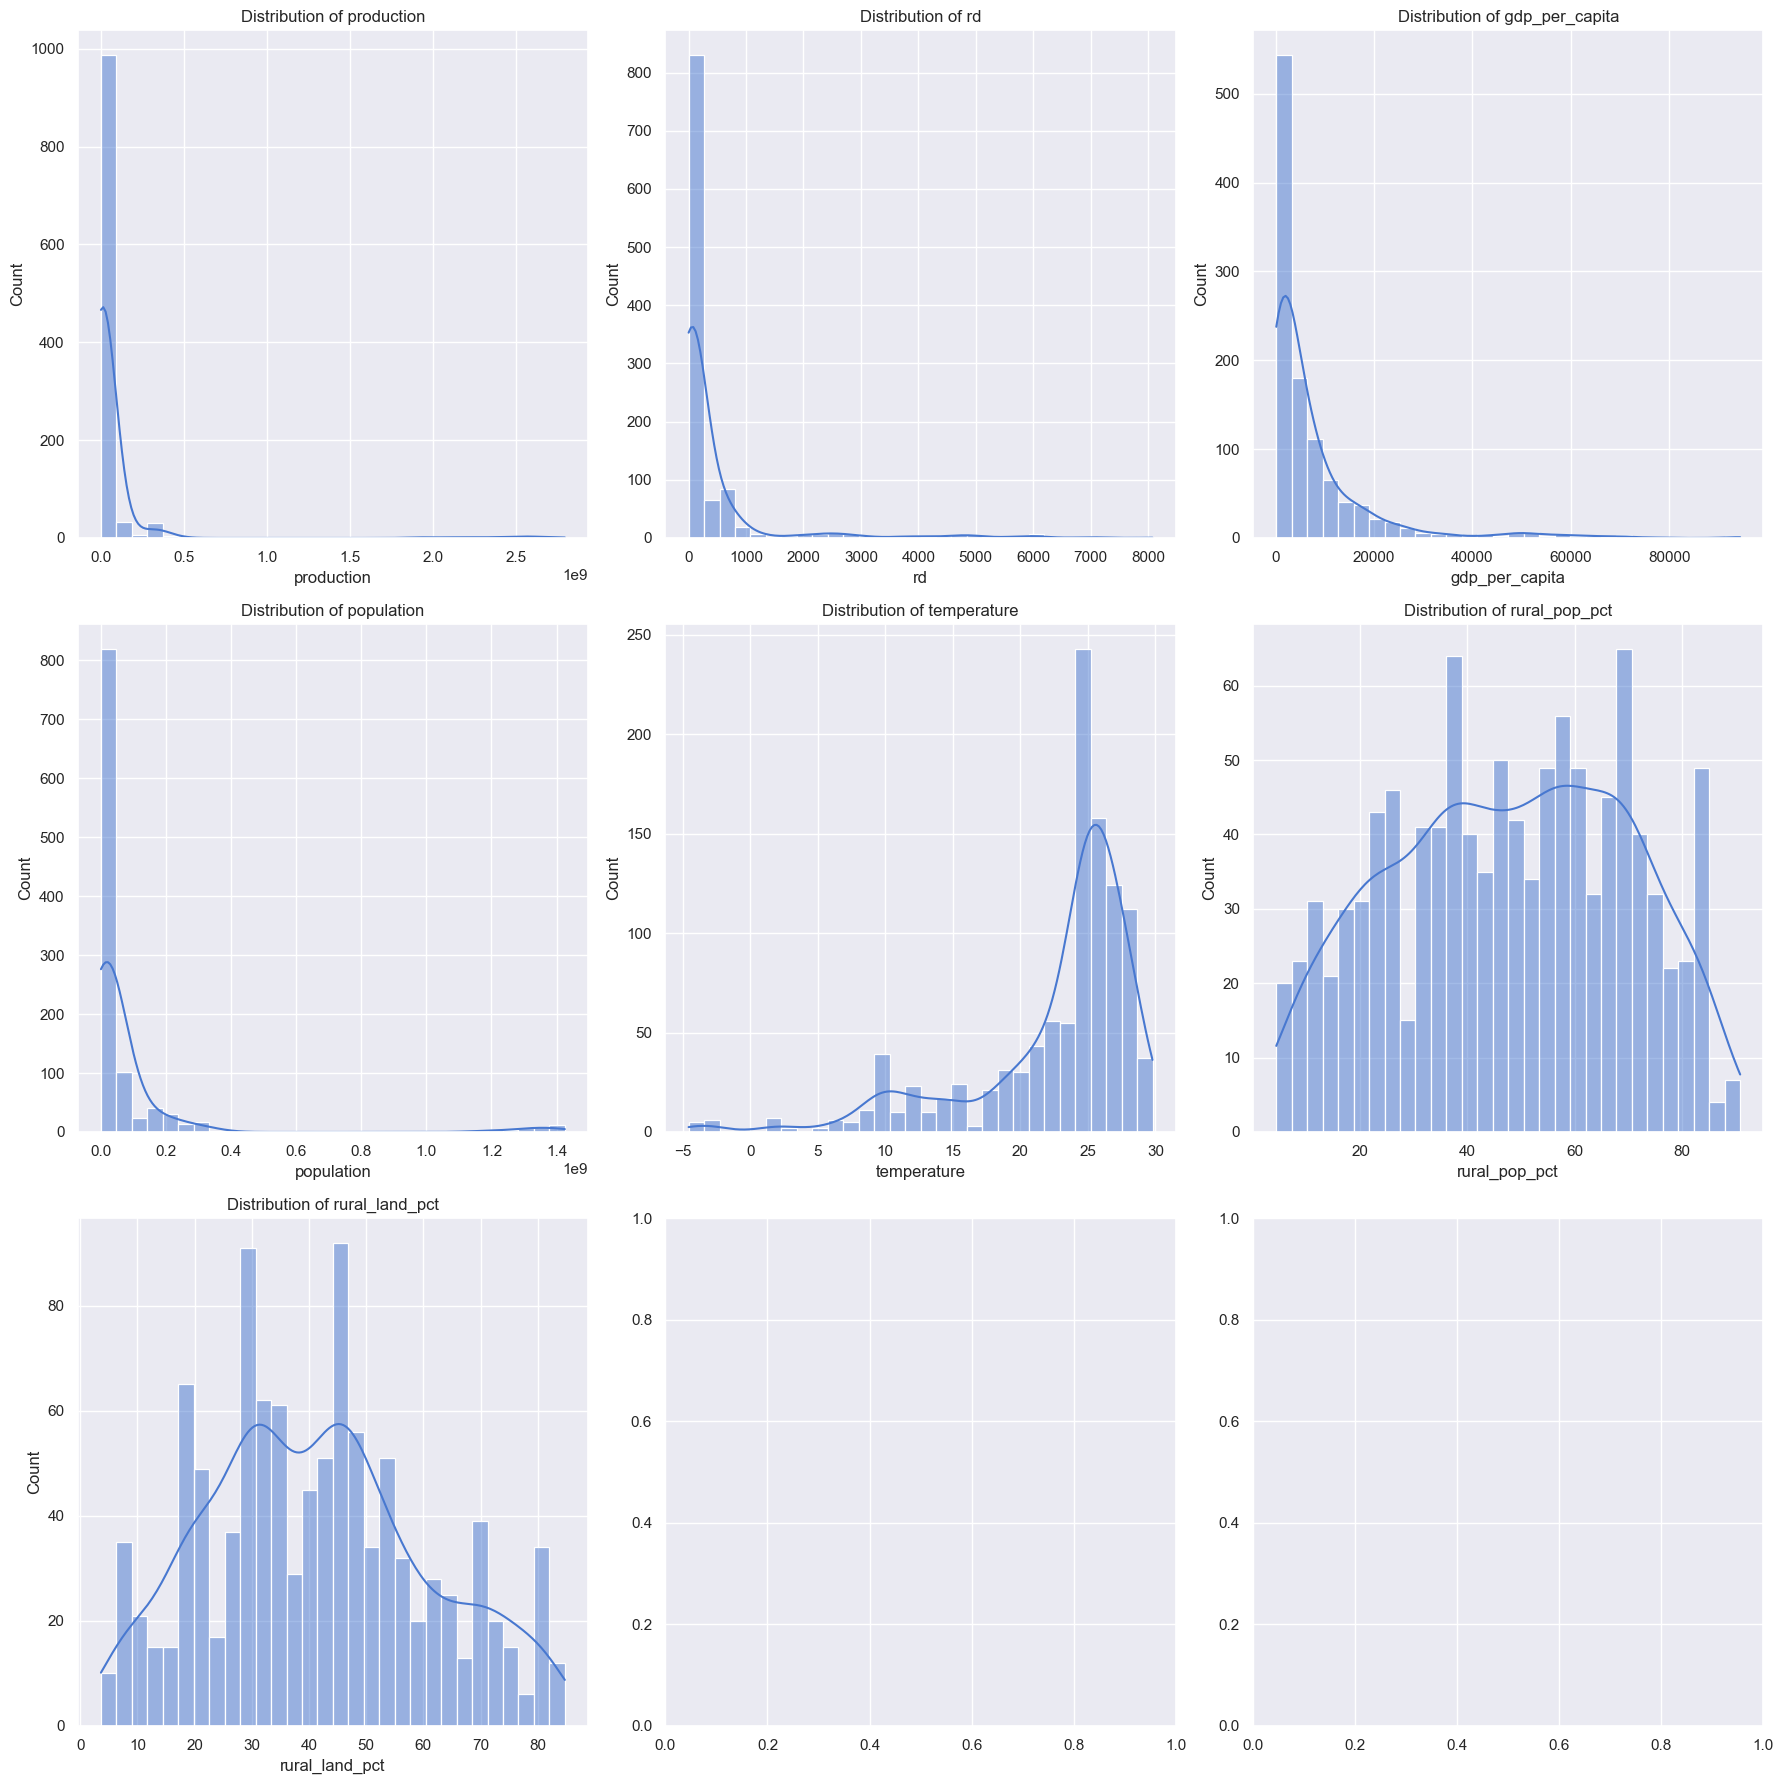

In [14]:
variables = [
    "production",
    "rd",
    "gdp_per_capita",
    "population",
    "temperature",
    "rural_pop_pct",
    "rural_land_pct"
]

fig, axes = plt.subplots(3,3, figsize=(18,18))
axes=axes.flatten()

for i, var in enumerate(variables):
    sns.histplot(df[var], bins=30, kde=True, ax=axes[i]) # type: ignore
    axes[i].set_title(f"Distribution of {var}")

plt.tight_layout()
plt.show()

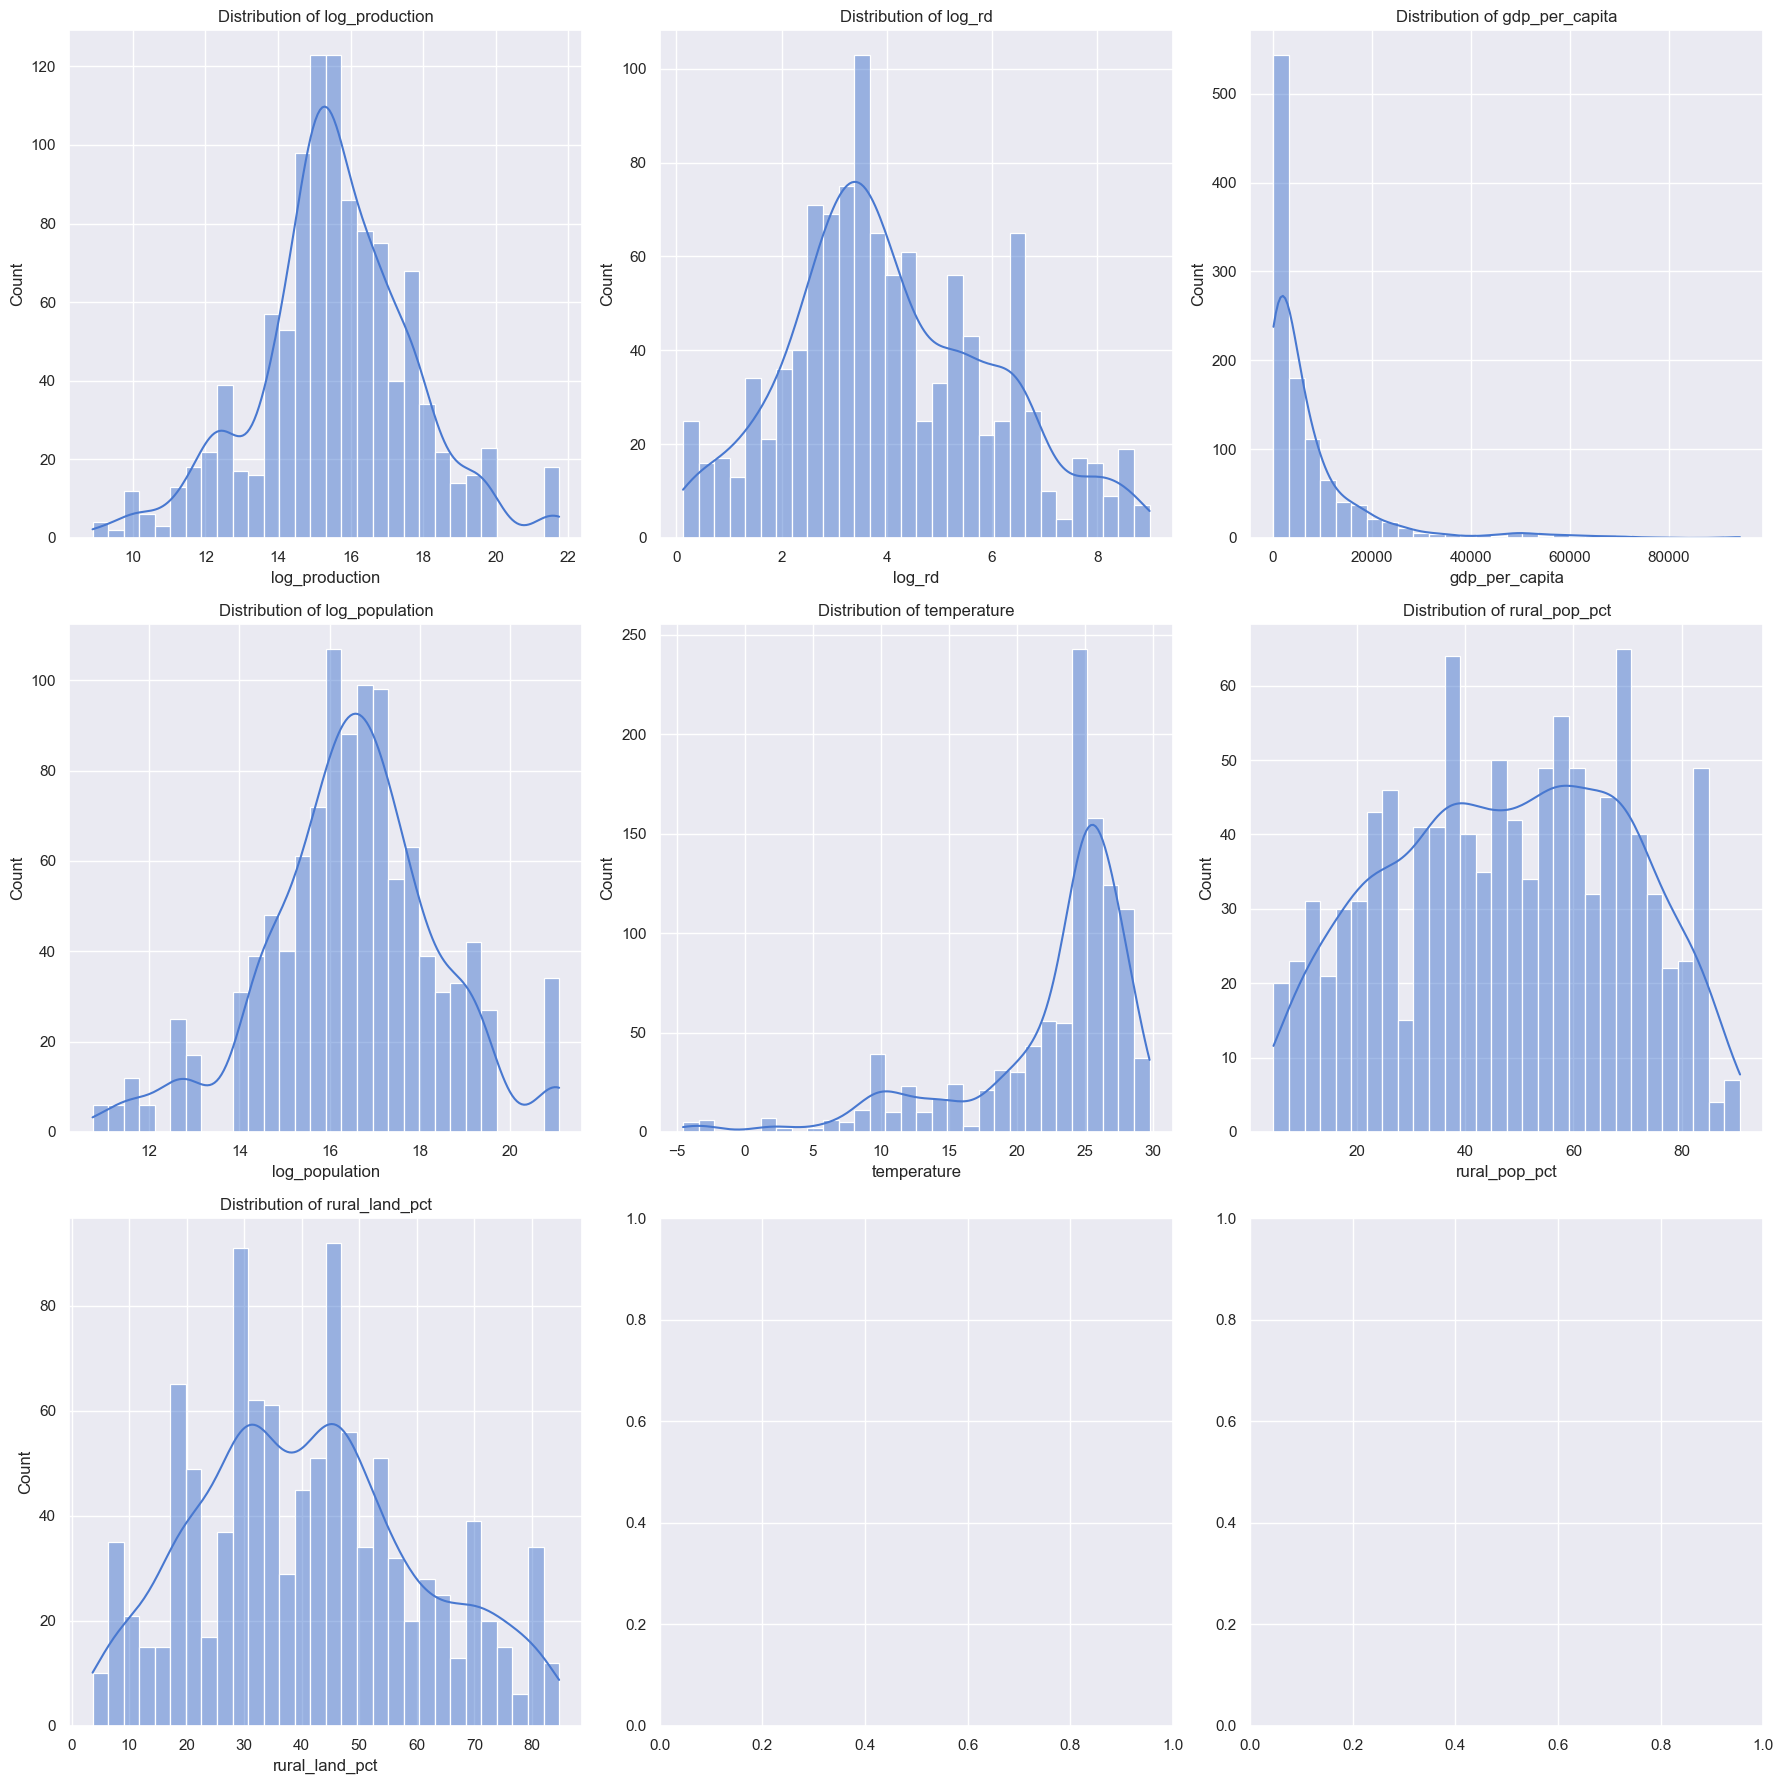

In [15]:
variables = [
    "log_production",
    "log_rd",
    "gdp_per_capita",
    "log_population",
    "temperature",
    "rural_pop_pct",
    "rural_land_pct"
]

fig, axes = plt.subplots(3,3, figsize=(18,18))
axes=axes.flatten()

for i, var in enumerate(variables):
    sns.histplot(df[var], bins=30, kde=True, ax=axes[i]) # type: ignore
    axes[i].set_title(f"Distribution of {var}")

plt.tight_layout()
plt.show()

### 4. Outlier Analysis

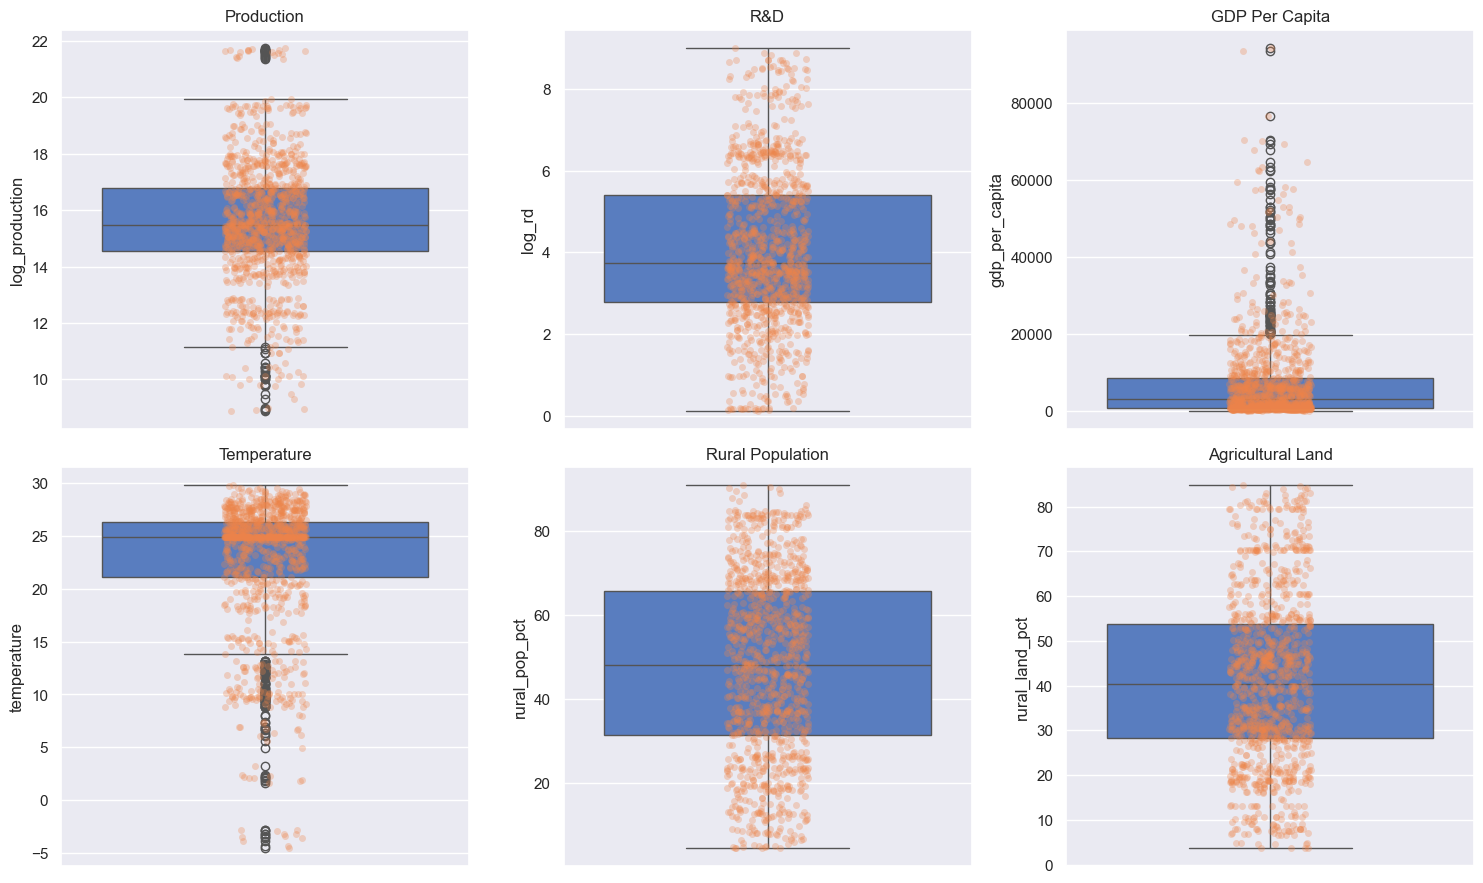

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

sns.boxplot(y=df["log_production"], ax=axes[0,0])
sns.stripplot(y=df["log_production"], alpha=0.3, ax=axes[0,0])
axes[0,0].set_title("Production")

sns.boxplot(y=df["log_rd"], ax=axes[0,1])
sns.stripplot(y=df["log_rd"], alpha=0.3, ax=axes[0,1])
axes[0,1].set_title("R&D")

sns.boxplot(y=df["gdp_per_capita"], ax=axes[0,2])
sns.stripplot(y=df["gdp_per_capita"], alpha=0.3, ax=axes[0,2])
axes[0,2].set_title("GDP Per Capita")

sns.boxplot(y=df["temperature"], ax=axes[1,0])
sns.stripplot(y=df["temperature"], alpha=0.3, ax=axes[1,0])
axes[1,0].set_title("Temperature")

sns.boxplot(y=df["rural_pop_pct"], ax=axes[1,1])
sns.stripplot(y=df["rural_pop_pct"], alpha=0.3, ax=axes[1,1])
axes[1,1].set_title("Rural Population")

sns.boxplot(y=df["rural_land_pct"], ax=axes[1,2])
sns.stripplot(y=df["rural_land_pct"], alpha=0.3, ax=axes[1,2])
axes[1,2].set_title("Agricultural Land")

plt.tight_layout()
plt.show()

In [17]:
# IQR method 
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    print(f"-- {column} --")
    print(f"Lower bound: {lower:.2f}")
    print(f"Upper bound: {upper:.2f}")
    print(f"Number of outliers: {len(outliers)}\n")

    return outliers

out_prod = detect_outliers_iqr(df, "log_production")
out_gdp = detect_outliers_iqr(df, "gdp_per_capita")
out_temp = detect_outliers_iqr(df, "temperature")

-- log_production --
Lower bound: 11.14
Upper bound: 20.19
Number of outliers: 47

-- gdp_per_capita --
Lower bound: -10502.60
Upper bound: 20002.70
Number of outliers: 95

-- temperature --
Lower bound: 13.19
Upper bound: 34.27
Number of outliers: 126



In [18]:
out_prod[["Country", "year", "production", "log_production"]]

,Country,year,production,log_production
4,Antigua and Barbuda,2007,2.471100e+04,10.115044
5,Antigua and Barbuda,2008,2.517500e+04,10.133646
6,Antigua and Barbuda,2009,2.416800e+04,10.092826
7,Antigua and Barbuda,2010,1.816000e+04,9.807032
8,Antigua and Barbuda,2011,1.878900e+04,9.841080
9,Antigua and Barbuda,2012,1.766800e+04,9.779567
99,Botswana,2005,2.197400e+04,9.997661
100,Botswana,2006,2.514800e+04,10.132573
101,Botswana,2007,2.230700e+04,10.012701
102,Botswana,2008,2.528600e+04,10.138046


In [19]:
out_gdp[["Country", "year", "gdp_per_capita"]]

,Country,year,gdp_per_capita
28,Australia,2006,36658.82435
29,Australia,2008,49811.20672
30,Australia,2010,52313.89390
31,Australia,2011,62799.38950
48,Barbados,2010,20610.51507
...,...,...,...
1018,United States of America,2019,64746.45068
1019,United States of America,2020,63515.94918
1020,United States of America,2021,70205.05092
1021,United States of America,2022,76657.24888


In [20]:
out_temp[["Country", "year", "temperature"]].head(30)

,Country,year,temperature
51,Belarus,2022,7.98
52,Belgium,2021,10.48
53,Belgium,2022,11.98
129,Bulgaria,2022,12.28
224,Chile,2005,9.14
225,Chile,2006,9.56
226,Chile,2007,8.77
227,Chile,2008,9.54
228,Chile,2009,9.41
229,Chile,2010,9.10


In [21]:
# ---- Z-score method ----
# production
df["z_prod"] = zscore(df["log_production"])
outliers_z = df[abs(df["z_prod"]) > 3]
outliers_z[["Country", "year", "log_production","z_prod"]]

,Country,year,log_production,z_prod
841,Saint Kitts and Nevis,2007,8.887515,-3.104953
842,Saint Kitts and Nevis,2008,8.944942,-3.078247
843,Saint Kitts and Nevis,2009,8.918784,-3.090411
844,Saint Kitts and Nevis,2010,8.984944,-3.059643


In [22]:
# gdp
df["z_gdp"] = zscore(df["gdp_per_capita"])
outliers_z = df[abs(df["z_gdp"]) > 3]
outliers_z[["Country", "year", "gdp_per_capita","z_gdp"]]

,Country,year,gdp_per_capita,z_gdp
29,Australia,2008,49811.20672,3.582261
30,Australia,2010,52313.89390,3.794318
31,Australia,2011,62799.38950,4.682775
52,Belgium,2021,51658.23829,3.738763
53,Belgium,2022,50605.74967,3.649584
328,Denmark,2021,69340.73349,5.237035
329,Denmark,2022,67781.09409,5.104884
395,Finland,2021,53099.13514,3.860853
396,Finland,2022,50440.56022,3.635587
397,France,2021,43725.09995,3.066573


In [23]:
# temperature
df["z_temp"] = zscore(df["temperature"])
outliers_z = df[abs(df["z_temp"]) > 3]
outliers_z[["Country", "year", "temperature","z_temp"]]

,Country,year,temperature,z_temp
395,Finland,2021,2.34,-3.259727
396,Finland,2022,3.24,-3.114927
490,Iceland,2005,1.58,-3.382001
491,Iceland,2006,2.17,-3.287077
492,Iceland,2007,2.05,-3.306384
493,Iceland,2008,1.80,-3.346606
494,Iceland,2009,2.09,-3.299949
495,Iceland,2010,2.27,-3.270989
496,Iceland,2011,1.89,-3.332126
818,Russian Federation,2006,-4.56,-4.369853


### 5. Correlation Analysis

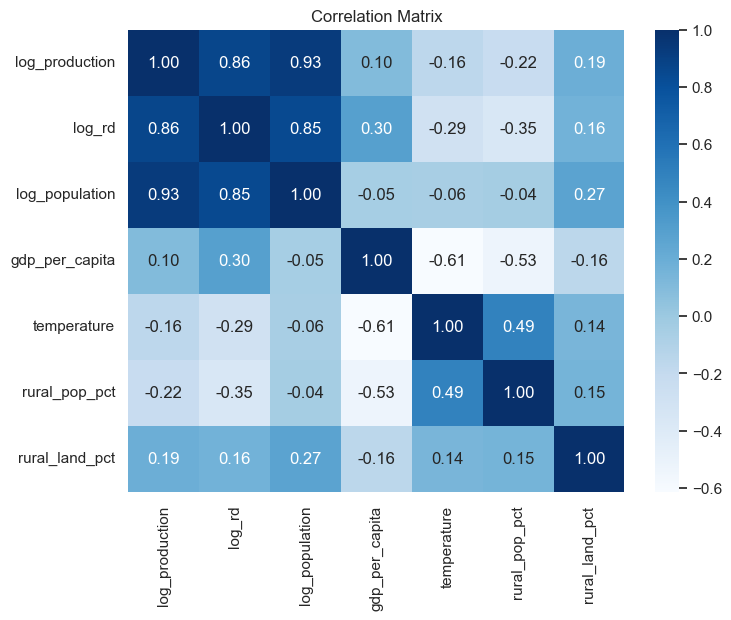

In [26]:
corr_var = ['log_production', "log_rd", 'log_population', 'gdp_per_capita', 'temperature', 'rural_pop_pct', 'rural_land_pct']

plt.figure(figsize=(8,6))
sns.heatmap(df[corr_var].corr(), annot=True, fmt=".2f", cmap='Blues')
plt.title("Correlation Matrix")
plt.show()

### 6. Dependences

<Figure size 1400x500 with 0 Axes>

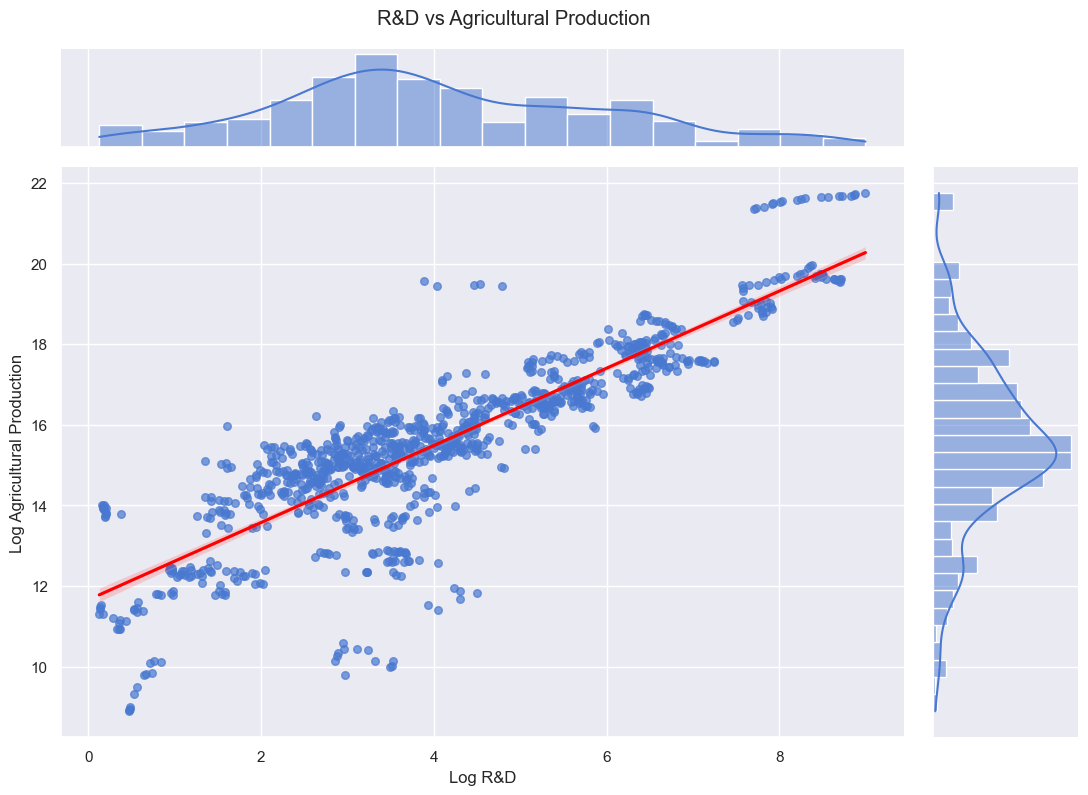

In [27]:
# --- R&D vs Production ---
plt.figure(figsize=(14,5))
g = sns.jointplot(data=df, x="log_rd", y="log_production", kind="reg", height=6, scatter_kws={"alpha": 0.7, "s": 30}, line_kws={"color": "red"})
g.fig.set_size_inches(12, 8) 
g.set_axis_labels(
    "Log R&D",
    "Log Agricultural Production"
)
g.fig.suptitle(
    "R&D vs Agricultural Production",
    y=1.02
    
)
plt.show()

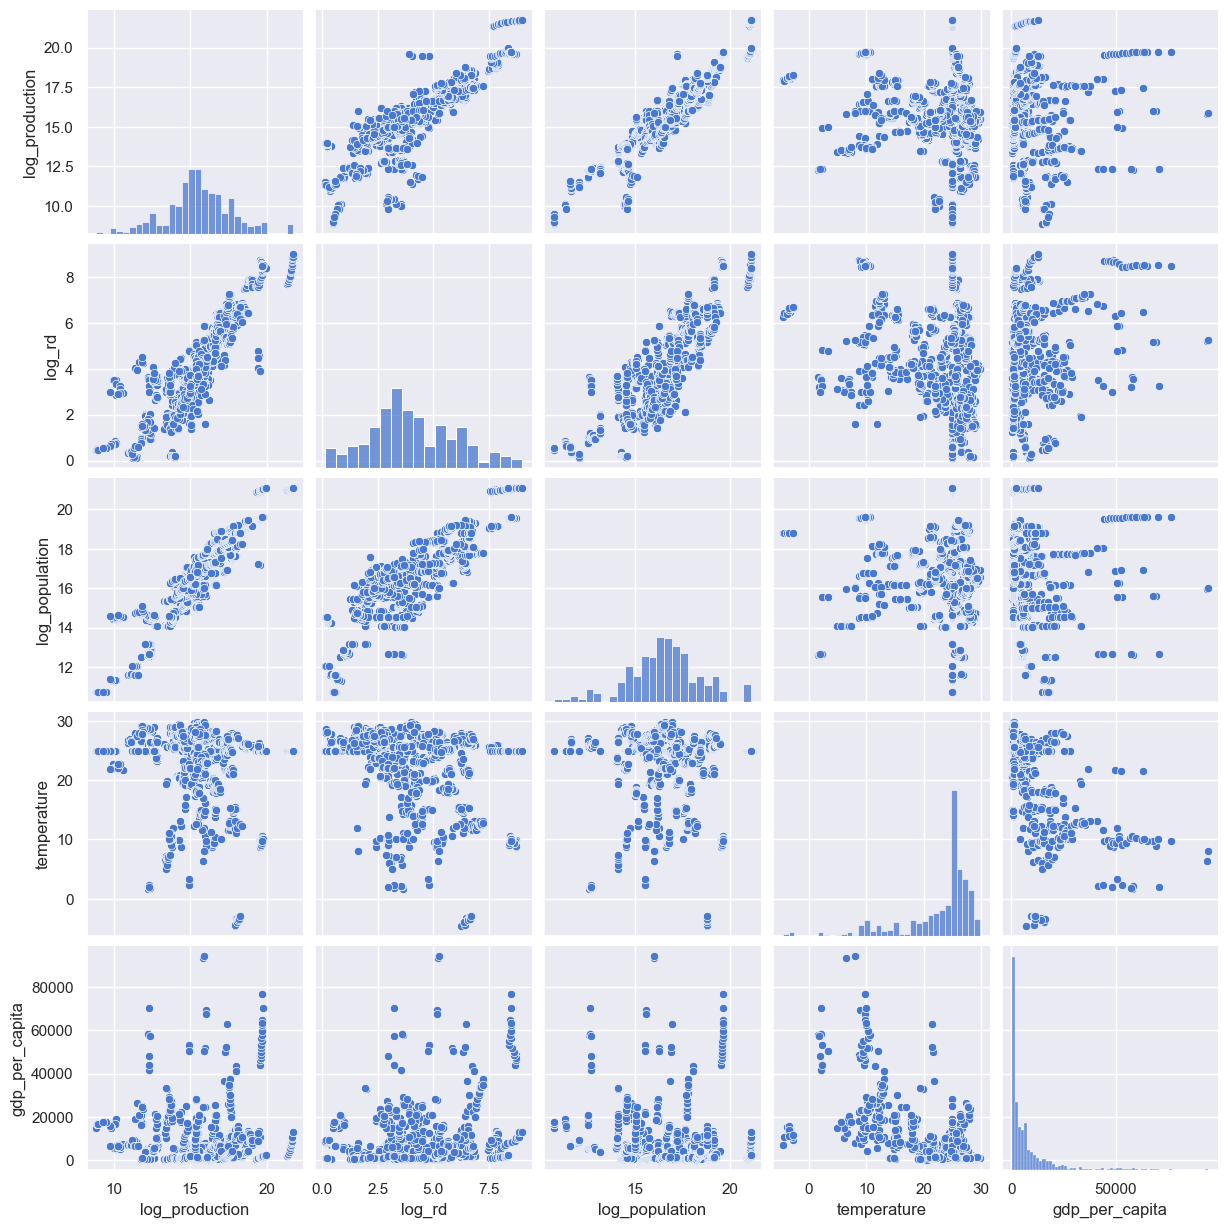

In [28]:
cols = [
    "log_production", "log_rd", "log_population","temperature", "gdp_per_capita"
]

sns.pairplot(df[cols])
plt.show()

### 7. Global trends

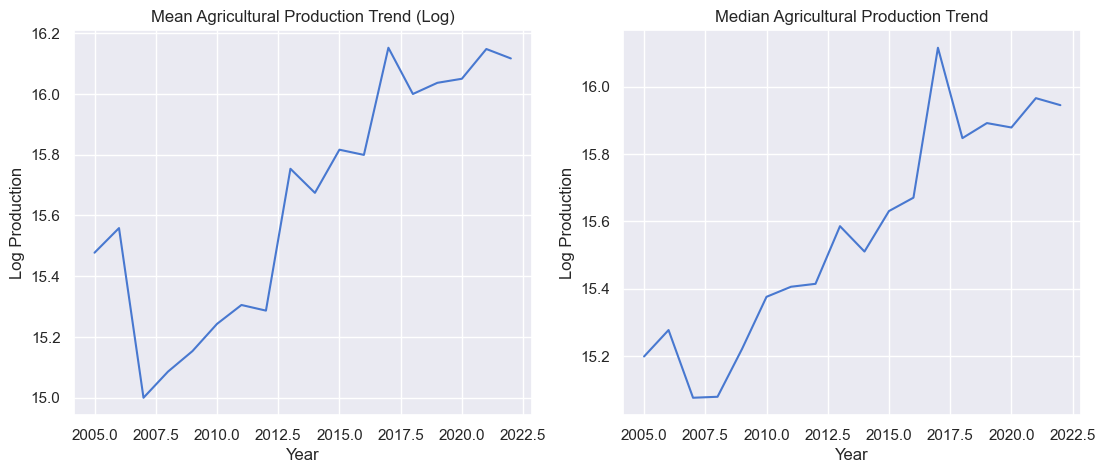

In [29]:
global_trend = df.groupby("year")["log_production"].mean().reset_index()
trend = df.groupby("year")["log_production"].median().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].plot(global_trend["year"], global_trend["log_production"])
axes[0].set_title("Mean Agricultural Production Trend (Log)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Log Production")

axes[1].plot(trend["year"], trend["log_production"])
axes[1].set_title("Median Agricultural Production Trend")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Log Production")

plt.grid(True)
plt.show()

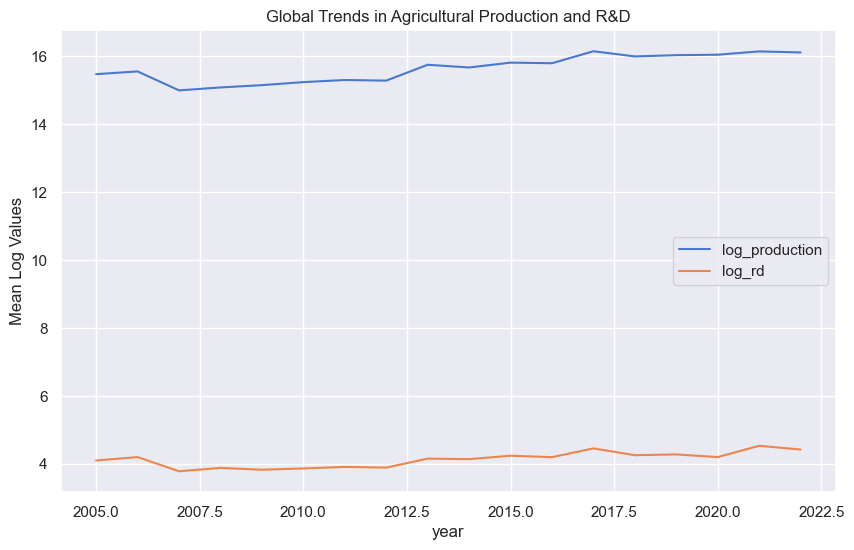

In [30]:
trend = df.groupby("year")[["log_production", "log_rd"]].mean()
trend.plot(figsize=(10,6))
plt.title("Global Trends in Agricultural Production and R&D")
plt.ylabel("Mean Log Values")
plt.show()

### 8. Tom vs Bottom Countries 

In [31]:
country_rank_prod = df.groupby('Country')['log_production'].mean().reset_index()

top_prod = country_rank_prod.nlargest(10, "log_production")
botom_prod = country_rank_prod.nsmallest(10, "log_production")

print(f'--- Biggest Agricultural Production ---\n{top_prod}')
print(f'\n--- Lowest Agricultural Production ---\n{botom_prod}')

--- Biggest Agricultural Production ---
                                Country  log_production
23                                China       21.584704
104            United States of America       19.658757
50                                India       19.636108
106  Venezuela (Bolivarian Republic of)       19.482948
13                               Brazil       18.854549
51                            Indonesia       18.554634
82                   Russian Federation       18.112106
101                             Türkiye       18.096224
40                               France       17.990179
71                              Nigeria       17.874980

--- Lowest Agricultural Production ---
                             Country  log_production
84             Saint Kitts and Nevis        9.092357
1                Antigua and Barbuda        9.961533
12                          Botswana       10.220966
44                           Grenada       11.028468
85                       Saint Lucia   

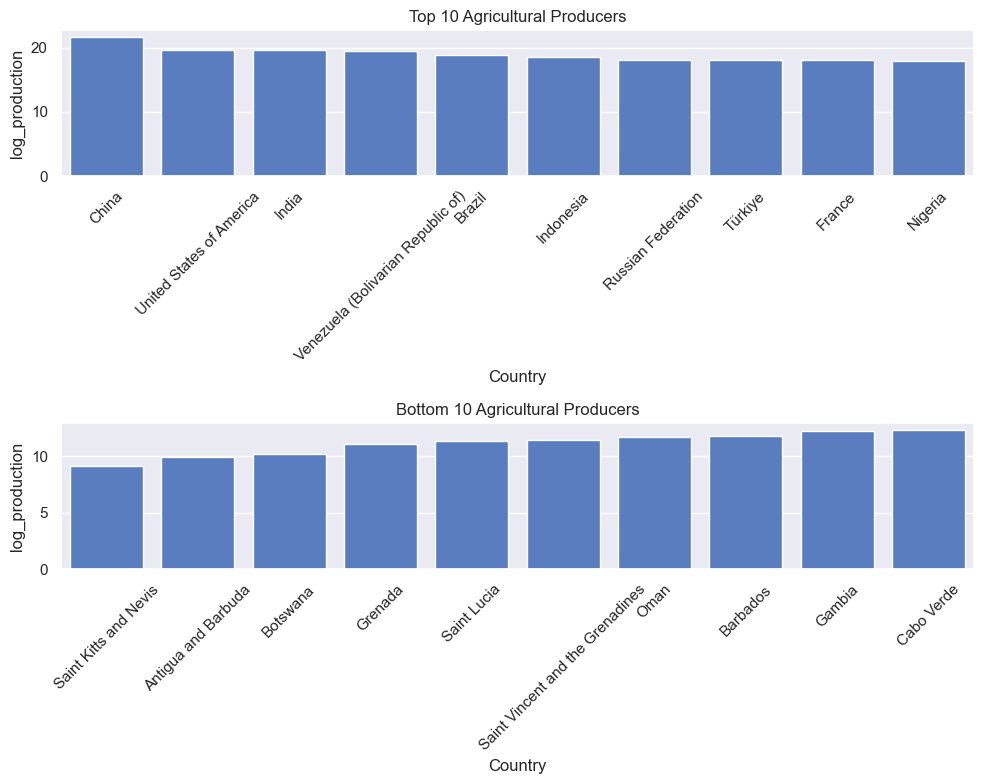

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(10,8))

sns.barplot(data=top_prod, x="Country", y="log_production", ax=axes[0])
axes[0].set_title("Top 10 Agricultural Producers")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=botom_prod, x="Country", y="log_production", ax=axes[1])
axes[1].set_title("Bottom 10 Agricultural Producers")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [33]:
# --- Top countries in the latest available year ---
latest_year = df["year"].max()

latest_prod = (
    df[df["year"] == latest_year]
    [["Country", "production", "log_production"]]
    .sort_values("production", ascending=False)
)

print(f"\n--- Top 20 Countries by Production (Latest Year: {latest_year}) ---\n")
print(latest_prod.head(20))


--- Top 20 Countries by Production (Latest Year: 2022) ---

                       Country    production  log_production
257                      China  2.792037e+09       21.750037
512                      India  4.638943e+08       19.955167
1021  United States of America  3.627587e+08       19.709249
128                     Brazil  1.898505e+08       19.061748
987                    Türkiye  9.556436e+07       18.375310
731                    Nigeria  7.355731e+07       18.113575
398                     France  6.491658e+07       17.988614
27                   Argentina  6.197024e+07       17.942165
1062                  Viet Nam  5.056005e+07       17.738672
926                      Spain  4.373589e+07       17.593680
814          Republic of Korea  4.194470e+07       17.551863
275                   Colombia  2.790135e+07       17.144186
988                    Ukraine  2.543601e+07       17.051677
925               South Africa  2.307309e+07       16.954177
612                   Ma

In [34]:
country_rank_rd = df.groupby('Country')['log_rd'].mean().reset_index()

top_rd = country_rank_rd.nlargest(10, "log_rd")
botom_rd = country_rank_rd.nsmallest(10, "log_rd")

print(f'--- Biggest Agricultural R&D Expenditures ---\n{top_rd}')
print(f'\n--- Lowest Agricultural R&D Expenditures ---\n{botom_rd}')

--- Biggest Agricultural R&D Expenditures ---
                      Country    log_rd
104  United States of America  8.555404
23                      China  8.328248
50                      India  7.988623
13                     Brazil  7.742457
79          Republic of Korea  6.955233
40                     France  6.780496
93                      Spain  6.614375
51                  Indonesia  6.606580
64                     Mexico  6.560679
97                   Thailand  6.533217

--- Lowest Agricultural R&D Expenditures ---
                             Country    log_rd
85                       Saint Lucia  0.165489
46                     Guinea-Bissau  0.197563
44                           Grenada  0.369685
84             Saint Kitts and Nevis  0.500573
86  Saint Vincent and the Grenadines  0.565986
1                Antigua and Barbuda  0.728950
6                           Barbados  0.893299
9                             Belize  1.029349
17                        Cabo Verde  1.46313

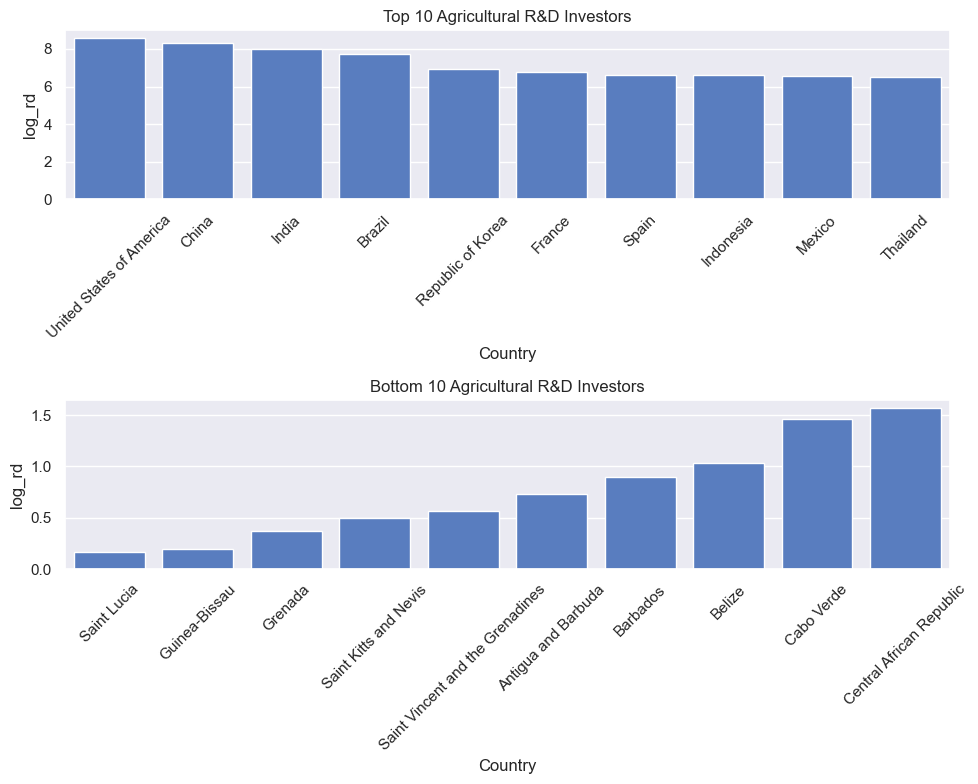

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(10,8))

sns.barplot(data=top_rd, x="Country", y="log_rd", ax=axes[0])
axes[0].set_title("Top 10 Agricultural R&D Investors")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=botom_rd, x="Country", y="log_rd", ax=axes[1])
axes[1].set_title("Bottom 10 Agricultural R&D Investors")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [36]:
df["rd_group"] = pd.qcut(
    df["log_rd"],
    q=4,
    labels=["Low","Medium","High","Very High"]
)

df.groupby("rd_group")["production"].mean()

rd_group
Low          1.713872e+06
Medium       3.589036e+06
High         1.649040e+07
Very High    2.465800e+08
Name: production, dtype: float64

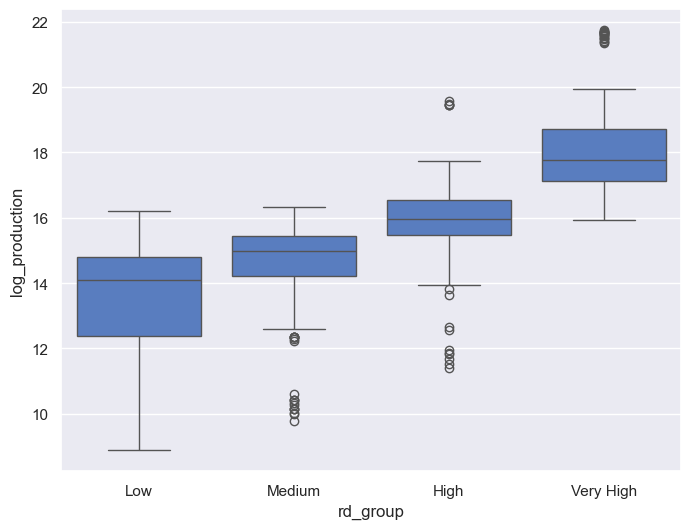

In [37]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="rd_group", y="log_production")
plt.show()

### EDA Findings
- Missing values of the merged dataset were filled using interpolation, country-level mean, and  final global fallback.
- **Distribution Analysis:**
	- Right-skewed: production, rd, gdp_growth, and population (concentrated near zero).
	- Left-skewed: temperature (dominated by 20-30 degrees).
	- Multimodal & Widely Spread: rural_pop_pct and rural_land_pct
	- Logarithmic transformation substantially improved distribution symmetry and reduced the influence of extreme observations.
- **Outliers Analysis:**
	- Was conducted using boxplots, interquartile range (IQR), and z-score methods. 
	- Several extreme observations were identified, particularly in GDP, temperature variables, and agricultural production.
	- Most outliners reflect economic or environmental characteristics of particular countries rather than data recording errors. 
- **Correlation Analysis:**
	- Strong positive correlation (>0.7): log production and log rd, log production and log population, log rd and log population.
	- Moderate positive correlation (~0.4): log rd and gdp, temperature and rural pop percentage.
	- Strong negative correlation (>-0.5): gdp and temperature, gdp and rural population percentage.
	- Moderate negative correlation (~-0.3): log rd and temperature, log rd and rural population percentage.
	- R&D expenditures and agricultural production demonstrated a visible positive linear association.
- **Trend Analysis:**
	- Global agricultural production and agricultural R&D expenditures demonstrated an overall upward trend over time, despite several noticeable declines.
- **Country-Level Analysis:**
	- Biggest Agricultural Production: China, United States of America, India, Venezuela, Brazil, Indonesia, Congo, Dominica, Eswatini, Gabon.
	- Biggest Agricultural R&D Expenditures: United States of America, China, India, Brazil, Republic of Korea, France, Spain, Indonesia, Mexico, Thailand.
	- Lowest Agricultural Production: Saint Kitts and Nevis, Antigua and Barbuda, Botswana, Grenada, Saint Lucia, Saint Vincent and the Grenadines, Oman, Barbados, Gambia, Cabo Verde.
	- Lowest Agricultural R&D Expenditures: Saint Lucia, Guinea-Bissau, Dominica, Grenada, Saint Kitts and Nevis, Saint Vincent and the Grenadines, Antigua and Barbuda, Gabon, Barbados, Belize.

## Hypotheses Evaluation:

**H1: Agricultural R&D expenditures have a positive effect on agricultural production.**
  
*Not Supported*. No significant contemporaneous effect was found, but positive effects emerge in lagged specifications.

**H2: The impact of agricultural R&D expenditures is delayed and becomes visible over time.**

*Partially Supported*. Lagged R&D variables (especially 3–5 year lags) show positive coefficients, but most are not statistically significant. Evidence suggests a possible delayed effect, but it is not robust.

**H3: Higher temperature negatively affects agricultural production.**
  
*Partially Supported*. Temperature is statistically significant and negative in the fixed effects model, but not robust across all specifications (insignificant in baseline and nonlinear models). 

**H4: Countries with a higher share of rural population exhibit lower production stability and higher volatility.**

*Partially Supported*. Rural population share is negatively associated with production levels in some models and shows mixed or weak effects in the stability regression.

**H5: Larger population size is positively associated with agricultural production levels.**

*Supported*. Population size is consistently positive and highly statistically significant across all model specifications, including baseline and fixed effects models.
